# 2. Strategy A backtest: crowding-filtered G10 carry

**Hypothesis (fixed before testing).** Carry trades earn a premium but crash when crowded positions unwind (Brunnermeier, Nagel & Pedersen 2008). When speculators are heavily long the high-rate currencies and short the low-rate ones, crash risk is higher, so we cut exposure.

This notebook runs the same functions as `code/02_backtest_strategyA.py`, step by step.

In [1]:
# Setup: run everything from the project root so the scripts' relative paths work
import os, importlib.util
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
%matplotlib inline

def load_script(path, name):
    """Import a numbered script from code/ (file names starting with a digit can't be imported normally)."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

Working directory: /Users/reza/Desktop/mfe-term_3/currency_market/currency-crypto-carry


In [2]:
S = load_script("code/02_backtest_strategyA.py", "stratA")
print("Currencies:", S.CCYS, "| legs:", S.N_LEG, "| z-window:", S.Z_WINDOW, "months",
      "| crowded if >", S.CROWD_THRESHOLD, "| exposure when crowded:", S.CROWDED_SCALE,
      "| cost:", S.TC_BP, "bp | in-sample ends", S.IN_SAMPLE_END)

Currencies: ['JPY', 'EUR', 'GBP', 'CHF', 'CAD', 'AUD', 'NZD'] | legs: 2 | z-window: 36 months | crowded if > 1.0 | exposure when crowded: 0.5 | cost: 3.0 bp | in-sample ends 2010-12-31


## Step 1 - load data and compute currency excess returns
Excess return of holding currency *k* for a month, funded in USD (covered interest parity):

$rx_{t} = (1 + i_{k,t-1}/1200)\,S_t/S_{t-1} - (1 + i_{US,t-1}/1200)$

In [3]:
spot, rates, weekly = S.load()
rx = S.excess_returns(spot, rates)
rate_diff = rates[S.CCYS].sub(rates["USD"], axis=0)
tradable = spot.notna() & rates[S.CCYS].notna()
rx.describe().T[["count", "mean", "std"]].assign(mean_pct_pa=lambda d: 1200 * d["mean"])

,count,mean,std,mean_pct_pa
JPY,291.0,-0.001811,0.026783,-2.172814
EUR,330.0,-0.000174,0.026481,-0.209225
GBP,660.0,0.000746,0.028322,0.894831
CHF,324.0,0.000723,0.028042,0.867981
CAD,666.0,0.000169,0.019095,0.202924
AUD,666.0,0.001579,0.031136,1.894383
NZD,631.0,0.001786,0.034160,2.142645


## Step 2 - carry portfolio
Each month-end: long the 2 highest-rate currencies, short the 2 lowest, equal weights (dollar-neutral).

In [4]:
w_carry = S.carry_weights(rate_diff, tradable)
print("Latest weights:"); w_carry.iloc[-1].to_frame("weight")

Latest weights:


,weight
JPY,0.0
EUR,0.0
GBP,0.0
CHF,-0.5
CAD,-0.5
AUD,0.5
NZD,0.5


In [5]:
share_long = (w_carry > 0).mean().sort_values(ascending=False)
share_short = (w_carry < 0).mean()
pd.DataFrame({"% of months long": 100 * share_long, "% of months short": 100 * share_short}).round(0)

,% of months long,% of months short
AUD,63.0,19.0
CAD,14.0,42.0
CHF,0.0,48.0
EUR,0.0,20.0
GBP,32.0,23.0
JPY,0.0,25.0
NZD,80.0,11.0


## Step 3 - crowding signal (alternative data)
CFTC positions are z-scored over 36 months and used only after their Friday release. Portfolio crowding = average z of the long leg minus average z of the short leg.

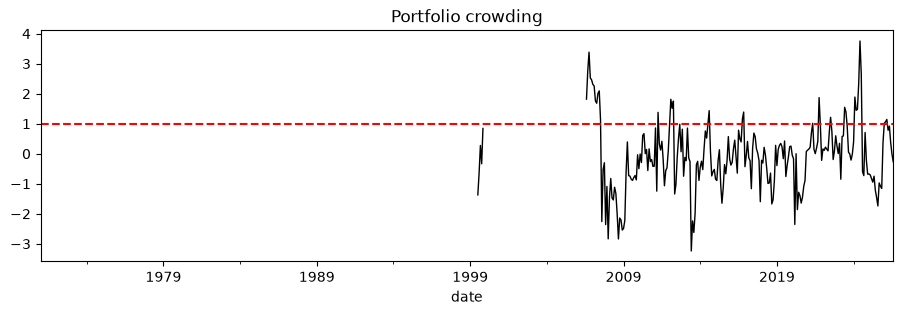

Crowded months: 33 of 247


In [6]:
crowd, z = S.crowding_signal(weekly, w_carry, spot.index)
scale = pd.Series(np.where(crowd > S.CROWD_THRESHOLD, S.CROWDED_SCALE, 1.0), index=crowd.index)
w_filt = w_carry.mul(scale, axis=0)
ax = crowd.plot(figsize=(11, 3), lw=1, color="black", title="Portfolio crowding")
ax.axhline(S.CROWD_THRESHOLD, color="red", ls="--"); plt.show()
print("Crowded months:", int((crowd > S.CROWD_THRESHOLD).sum()), "of", int(crowd.notna().sum()))

## Step 4 - backtest (with transaction costs)

In [7]:
g_c, n_c, to_c = S.backtest(w_carry, rx, S.TC_BP)
g_f, n_f, to_f = S.backtest(w_filt, rx, S.TC_BP)
start = crowd.first_valid_index()
series = {"Carry (gross)": g_c.loc[start:], "Carry (net)": n_c.loc[start:],
          "Crowd-filtered (gross)": g_f.loc[start:], "Crowd-filtered (net)": n_f.loc[start:]}
turns = {"Carry (gross)": to_c, "Carry (net)": to_c, "Crowd-filtered (gross)": to_f, "Crowd-filtered (net)": to_f}
table = S.split_table(series, turns)
table.round(2)

Start      End Months Ann. mean (%) Ann. vol (%)    Sharpe Max drawdown (%)  Skewness Worst month (%) Hit rate (%) Ann. turnover (x)
Carry (gross)          Full           1999-05  2026-08    327      3.307501     8.903673  0.371476       -36.883651 -0.485305      -12.006567    59.938838          1.211009
                       In-sample      1999-05  2010-12    140      5.009849    10.541805  0.475236       -36.883651 -0.713344      -12.006567    65.714286          1.628571
                       Out-of-sample  2011-01  2026-08    187      2.033015     7.455111  0.272701       -15.403319 -0.103055       -6.362511    55.614973          0.898396
Carry (net)            Full           1999-05  2026-08    327       3.27117     8.906761  0.367268        -37.00107 -0.485708      -12.036567    59.633028          1.211009
                       In-sample      1999-05  2010-12    140      4.958421     10.54687  0.470132        -37.00107 -0.713931      -12.036567         65.0          1.628571
                       Out-of-sample  2011-01  2026-08    187      2.007988     7.456599   0.26929       -15.453855 -0.101216       -6.362511    55.614973          0.898396
Crowd-filtered (gross) Full           1999-05  2026-08    327      3.291021     8.543317  0.385216       -36.873053 -0.448967      -12.006567    59.938838          1.963303
                       In-sample      1999-05  2010-12    140       4.52309    10.121303  0.446888       -36.873053 -0.683606      -12.006567    65.714286               1.8
                       Out-of-sample  2011-01  2026-08    187      2.368616     7.155696  0.331011       -14.319539 -0.017542       -6.362511    55.614973          2.085561
Crowd-filtered (net)   Full           1999-05  2026-08    327      3.232122     8.545066  0.378244       -36.990492 -0.449651      -12.036567    59.633028          1.963303
                       In-sample      1999-05  2010-12    140      4.466519    10.124852  0.441144       -36.990492 -0.685622      -12.036567         65.0               1.8
                       Out-of-sample  2011-01  2026-08    187      2.307974     7.155559  0.322543       -14.422096 -0.015027       -6.362511    55.614973          2.085561

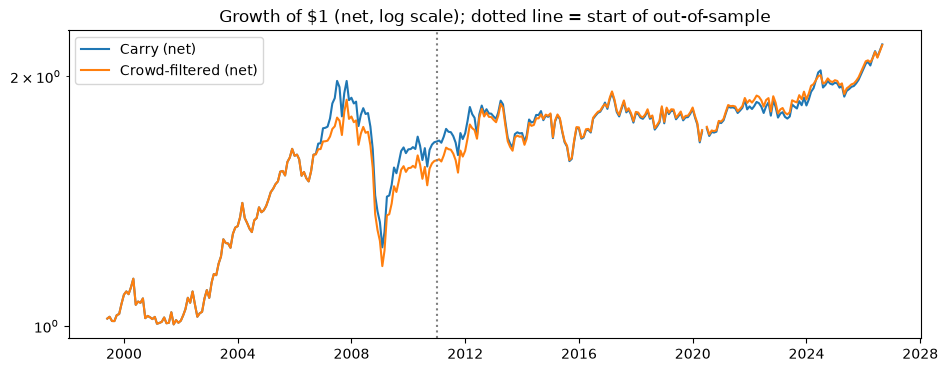

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
for name in ("Carry (net)", "Crowd-filtered (net)"):
    ax.plot((1 + series[name]).cumprod(), label=name)
ax.set_yscale("log"); ax.axvline(pd.Timestamp(S.IN_SAMPLE_END), color="grey", ls=":")
ax.set_title("Growth of $1 (net, log scale); dotted line = start of out-of-sample"); ax.legend(); plt.show()

## Step 5 - does crowding predict bad carry months?

In [9]:
nxt = n_c.loc[start:]
state = (crowd.shift(1) > S.CROWD_THRESHOLD).reindex(nxt.index)
pd.DataFrame({
    "Months": nxt.groupby(state).size(),
    "Next-month carry mean (%)": 100 * nxt.groupby(state).mean(),
    "Next-month carry vol (%)": 100 * nxt.groupby(state).std(),
    "Next-month skewness": nxt.groupby(state).skew(),
}).rename(index={False: "Not crowded", True: "Crowded"}).round(2)

,Months,Next-month carry mean (%),Next-month carry vol (%),Next-month skewness
Not crowded,295,0.30,2.56,-0.46
Crowded,33,0.02,2.67,-0.71


## Step 6 - robustness grid
All parameters were fixed before testing; the grid reports alternatives transparently.

In [10]:
pd.read_csv("output/strategyA/robustness_grid.csv").round(2)

,threshold,crowded_scale,Sharpe full,Sharpe OOS,MaxDD full (%)
0,0.5,0.0,0.37,0.31,-36.99
1,0.5,0.5,0.38,0.30,-36.99
2,1.0,0.0,0.38,0.37,-36.99
3,1.0,0.5,0.38,0.32,-36.99
4,1.5,0.0,0.35,0.39,-37.02
5,1.5,0.5,0.36,0.33,-36.99


*To regenerate every output file for Strategy A, run `python code/02_backtest_strategyA.py` from the project root.*